### Python implementation of Leen's Network (minimal)

This notebook is an example of code implementation of Leen's algorithm to find principal components. This notebook focuses on the core algorithm of the Leen's minimal network, which is a simplified version of the full Leen's network. The minimal network is designed to capture the essential features of the algorithm while accurately capturing all the PCs of the input data. 

The math derivations are below:

$$
\mathbf{y} = \mathbf{w} \mathbf{x}
$$

$$
S = (I + q) y
$$

$$
\Delta W_i = \eta_w (\langle x s_i \rangle - \gamma_w \langle y_i^2 \rangle w_i)
$$

$$
\Delta q_{ik} = \eta_q (\langle y_i^2 + y_k^2 \rangle) (- q_{ij} - C\langle y_i y_j \rangle), q_{ii} = 0
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import hebbian.utils as utils

In [2]:
class LeenMinimalPCA:
    """
    Activity-dependent Leen/Földiak PCA learner (NumPy).

    y = (I - q)^{-1} W x        # complete mode
    or y = W x                  # minimal mode (fast, robust for learning)

    Lateral (off-diagonal only):
        q_{ij} <- q_{ij} + η_q * (λ_i + λ_j) * ( - q_{ij} - C * <y_i y_j> )

    Forward (per unit i):
        w_i <- w_i + η_W * ( < x * s_i > - < y_i^2 > w_i )
        where s = y + q y  (vector per sample); i.e. s = (I + q) y

    Parameters
    ----------
    input_dim : int
    output_dim : int
    eta_w : float            # forward learning rate
    eta_q : float            # lateral learning rate (make this larger than eta_w)
    C : float                # coupling; pick > 1 (e.g., 1.5)
    ema_alpha : float        # EMA step for activity λ_i ≈ E[y_i^2]
    forward_mode : str       # "minimal", "complete", or "complete_first_order"
    symmetrize_q : bool      # keep q explicitly symmetric + zero diagonal after each step
    clip_q_spectral : float or None  # if not None, shrink q to keep ||q||_2 <= this value (e.g., 0.95)
    seed : int or None
    """
    def __init__(self,
                 input_dim: int,
                 output_dim: int,
                 eta_w: float = 1e-3,
                 eta_q: float = 1e-2,
                 C: float = 1.5,
                 ema_alpha: float = 0.05,
                 symmetrize_q: bool = True,
                 clip_q_spectral: float | None = None,
                 seed: int | None = 0):

        self.d = input_dim
        self.m = output_dim
        self.eta_w = eta_w
        self.eta_q = eta_q
        self.C = C
        self.ema_alpha = ema_alpha
        self.symmetrize_q = symmetrize_q
        self.clip_q_spectral = clip_q_spectral

        rng = np.random.default_rng(seed)
        # Row-wise unit-norm init for W
        W = rng.normal(size=(self.m, self.d))
        W /= np.linalg.norm(W, axis=1, keepdims=True) + 1e-12
        self.W = W
        # Symmetric zero-diagonal init for q
        self.q = np.zeros((self.m, self.m))
        np.fill_diagonal(self.q, 0.0)
        # EMA of activities (start small positive to avoid zero)
        self.lam = np.full(self.m, 1e-6)

    # ---------- helpers ----------

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """
        X: (B, d) -> Y: (B, m)
        """
        Y = X @ self.W.T  # (B, m) = W x
        return Y

    def _symmetrize_q(self):
        self.q = 0.5 * (self.q + self.q.T)
        np.fill_diagonal(self.q, 0.0)

    def _clip_q_spectral_norm(self):
        if self.clip_q_spectral is None:
            return
        # Spectral norm via SVD
        u, s, vt = np.linalg.svd(self.q, full_matrices=False)
        smax = s[0]
        if smax > self.clip_q_spectral:
            s = s * (self.clip_q_spectral / (smax + 1e-12))
            self.q = (u * s) @ vt
            self._symmetrize_q()

    # ---------- public API ----------

    def step(self, X: np.ndarray):
        """
        One learning step on a batch X: shape (B, d).
        """
        X = np.asarray(X, dtype=float)
        B = X.shape[0]

        # Forward pass
        Y = self._forward(X)                                     # (B, m)

        # Batch moments
        y_cov = (Y.T @ Y) / B                                    # (m, m)  ~ < y_i y_j >
        y_var = np.diag(y_cov).copy()                            # (m,)

        # EMA update of activities λ_i ~ E[y_i^2]
        self.lam = (1.0 - self.ema_alpha) * self.lam + self.ema_alpha * y_var

        # ----- Lateral update (off-diagonal) -----
        lam_sum = self.lam[:, None] + self.lam[None, :]          # (m, m)  (λ_i + λ_j)
        dq = self.eta_q * lam_sum * ( - self.q - self.C * y_cov )
        np.fill_diagonal(dq, 0.0)
        self.q += dq

        if self.symmetrize_q:
            self._symmetrize_q()
        self._clip_q_spectral_norm()

        # ----- Forward update (Hebb-Oja, gated by q) -----
        # s = (I + q) y  (per sample); with row-vectors: S = Y @ (I+q)^T
        S = Y @ (np.eye(self.m) + self.q).T                      # (B, m)
        # < x * s_i > as a matrix: (d, m) then transpose to (m, d)
        XS = (X.T @ S) / B                                       # (d, m)
        dW = self.eta_w * (XS.T - y_var[:, None] * self.W)       # (m, d)
        self.W += dW

        # Mild row renorm to avoid drift (Oja already stabilizes norms)
        row_norms = np.linalg.norm(self.W, axis=1, keepdims=True) + 1e-12
        self.W /= row_norms

    def transform(self, X: np.ndarray) -> np.ndarray:
        "Project X onto learned components (uses the current forward mode)."
        return self._forward(np.asarray(X, dtype=float))

    @property
    def components_(self) -> np.ndarray:
        "Rows of W are the learned components (unit-norm). Shape: (m, d)"
        return self.W.copy()



In [3]:
class LeenCompletePCA:
    """
    Implementation of Leen's "complete" PCA model (Section 4).

    In this model, the neuron's output `y` is calculated recurrently,
    meaning the lateral connections `q` (eta in the paper) directly
    influence the cell's response in a feedback loop.

    Equations of Motion (ensemble average form):
    -------------------------------------------
    Forward Pass (Eq. 33):
        y = (I - q)^-1 W x

    Forward Weight Update (Eq. 35):
        Δw = η_w * ( <y x^T> - Diag(<y y^T>) w )

    Lateral Connection Update (Activity-Dependent, Eq. 47):
        Δq_ij = η_q * ( (<y_i^2> + <y_j^2>) * q_ij - C * <y_i y_j> )

    Parameters
    ----------
    input_dim : int
    output_dim : int
    eta_w : float             # Forward learning rate
    eta_q : float             # Lateral learning rate (make this larger than eta_w)
    C : float                 # Coupling; pick > 1 (e.g., 1.5)
    ema_alpha : float         # EMA step for activity λ_i ≈ E[y_i^2]
    symmetrize_q : bool       # Keep q symmetric + zero diagonal after each step
    seed : int or None
    """
    def __init__(self,
                 input_dim: int,
                 output_dim: int,
                 eta_w: float = 1e-3,
                 eta_q: float = 1e-2,
                 C: float = 1.5,
                 ema_alpha: float = 0.05,
                 symmetrize_q: bool = True,
                 seed: int | None = 0, 
                 mode: str = "complete"):
        self.d = input_dim
        self.m = output_dim
        self.eta_w = eta_w
        self.eta_q = eta_q
        self.C = C
        self.ema_alpha = ema_alpha
        self.symmetrize_q = symmetrize_q
        self.mode = mode

        rng = np.random.default_rng(seed)
        # Row-wise unit-norm init for W
        W = rng.normal(size=(self.m, self.d))
        W /= np.linalg.norm(W, axis=1, keepdims=True) + 1e-12
        self.W = W
        # Symmetric zero-diagonal init for q
        self.q = np.zeros((self.m, self.m))
        # EMA of activities (start small positive to avoid zero)
        self.lam = np.full(self.m, 1e-6)

    # ---------- helpers ----------

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """
        Calculates the recurrent cell response y = (I - q)^-1 W x
        X: (B, d) -> Y: (B, m)
        """
        Z = X @ self.W.T  # (B, m), represents Wx
        if self.mode == "complete":
            L = np.eye(self.m) - self.q
            try:
                # Solves the linear system (I - q)y = Wx for y
                Y = np.linalg.solve(L, Z.T).T # calculate the inverse of L and multiply it by Z.T. The equation is L * Y = Z.T, so Y = L^-1 * Z.T. 
            except np.linalg.LinAlgError:
                print("Warning: Singular matrix in forward pass. Using pseudo-inverse.")
                L_inv = np.linalg.pinv(L)
                Y = Z @ L_inv.T
        elif self.mode == "first_order":
            Y = Z @ (np.eye(self.m) + self.q).T
        return Y

    def _symmetrize_q(self):
        self.q = 0.5 * (self.q + self.q.T)
        np.fill_diagonal(self.q, 0.0)

    # ---------- public API ----------

    def step(self, X: np.ndarray):
        """
        One learning step on a batch X: shape (B, d).
        """
        X = np.asarray(X, dtype=float)
        B = X.shape[0]

        # Forward pass (recurrent calculation)
        Y = self._forward(X)  # (B, m)

        # Batch moments from the complete response
        y_cov = (Y.T @ Y) / B      # (m, m) ~ <y y^T>
        y_var = np.diag(y_cov).copy()  # (m,)   ~ <y_i^2>

        # EMA update of activities λ_i ~ E[y_i^2]
        self.lam = (1.0 - self.ema_alpha) * self.lam + self.ema_alpha * y_var

        # ----- Lateral update (Activity-Dependent Anti-Hebbian) -----
        lam_sum = self.lam[:, None] + self.lam[None, :]  # (m, m) (λ_i + λ_j)
        # Implements Δq_ij = η_q * ( (λ_i + λ_j) * q_ij - C * <y_i y_j> )
        dq = self.eta_q * (lam_sum * self.q - self.C * y_cov)
        np.fill_diagonal(dq, 0.0)
        self.q += dq

        if self.symmetrize_q:
            self._symmetrize_q()

        # ----- Forward update (Hebb-Oja on complete response) -----
        # Implements Δw = η_w * ( <y x^T> - Diag(<y y^T>) w )
        hebb_term = (Y.T @ X) / B  # (m, d)
        oja_term = y_var[:, None] * self.W      # (m, d)
        dW = self.eta_w * (hebb_term - oja_term)
        self.W += dW

    def transform(self, X: np.ndarray) -> np.ndarray:
        "Project X onto learned components using the recurrent dynamics."
        return self._forward(np.asarray(X, dtype=float))

    @property
    def components_(self) -> np.ndarray:
        "Rows of W are the learned components. Shape: (m, d)"
        # Normalize for stability and consistency, as Oja's rule keeps them near norm 1
        W_norm = self.W.copy()
        W_norm /= np.linalg.norm(W_norm, axis=1, keepdims=True) + 1e-12
        return W_norm

In [4]:
# --- helpers ---
def best_match_alignment(W_rows, PC_rows):
    """
    W_rows: (m, d) learned components, row-normalized
    PC_rows: (m, d) true PCs, row-normalized in descending variance order
    Returns:
      perm: indices of PCs assigned to each W row
      corrs: absolute correlations after optimal assignment
      C: full |cosine| matrix (m x m)
    """
    # normalize
    Wn = W_rows / (np.linalg.norm(W_rows, axis=1, keepdims=True) + 1e-12)
    PCn = PC_rows / (np.linalg.norm(PC_rows, axis=1, keepdims=True) + 1e-12)
    # cosine matrix
    C = np.abs(Wn @ PCn.T)

        # Hungarian solves a min-cost problem; convert to cost = 1 - C
    r, c = linear_sum_assignment(1.0 - C)
        # # greedy fallback
        # C_copy = C.copy()
        # m = C.shape[0]
        # r, c = [], []
        # for _ in range(m):
        #     i, j = np.unravel_index(np.argmax(C_copy), C_copy.shape)
        #     r.append(i); c.append(j)
        #     C_copy[i, :] = -np.inf
        #     C_copy[:, j] = -np.inf
        # r = np.array(r); c = np.array(c)

    return c, C[np.arange(C.shape[0]), c], C


def true_pcs_rows(X, m):
    """Return top-m PCs as ROWS (shape m x d)."""
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, VT = np.linalg.svd(Xc, full_matrices=False)
    return VT[:m, :]  # rows are PCs


def subspace_max_angle_deg(W_rows, PC_rows):
    """Largest principal angle between the two m-dim subspaces (in degrees)."""
    # Orthonormal bases for colspaces of W^T and PC^T
    Qw, _ = np.linalg.qr(W_rows.T)
    Qp, _ = np.linalg.qr(PC_rows.T)
    s = np.linalg.svd(Qw.T @ Qp, compute_uv=False)
    return float(np.degrees(np.arccos(np.clip(s.min(), -1.0, 1.0))))



# ------ statistical helpers ------
def compute_eigen_decomposition(X, center_data=True, return_covariance=False):
    """
    Compute eigenvalues and eigenvectors from input data X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data matrix
    center_data : bool, default=True
        Whether to center the data (subtract mean) before computing covariance
    return_covariance : bool, default=False
        Whether to also return the covariance matrix
        
    Returns
    -------
    eigenvalues : ndarray, shape (n_features,)
        Eigenvalues in descending order
    eigenvectors : ndarray, shape (n_features, n_features)
        Eigenvectors as columns (each column is an eigenvector)
    covariance : ndarray, shape (n_features, n_features), optional
        Covariance matrix (only returned if return_covariance=True)
    """
    X = np.asarray(X, dtype=float)
    
    # Center the data if requested
    if center_data:
        X_centered = X - X.mean(axis=0, keepdims=True)
    else:
        X_centered = X
    
    # Compute covariance matrix
    n_samples = X_centered.shape[0]
    covariance = (X_centered.T @ X_centered) / (n_samples - 1)
    
    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    
    # Sort in descending order (largest eigenvalues first)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    if return_covariance:
        return eigenvalues, eigenvectors, covariance
    else:
        return eigenvalues, eigenvectors


def generate_covariance_matrix(dim, method='random', eigenvalues=None, condition_number=None, seed=None):
    """
    Generate a symmetric positive-semidefinite covariance matrix.
    
    Parameters
    ----------
    dim : int
        Dimension of the covariance matrix (dim x dim)
    method : str, default='random'
        Method to generate the matrix:
        - 'random': Random positive definite matrix
        - 'eigenvalues': Use specified eigenvalues
        - 'condition': Use specified condition number
        - 'toeplitz': Toeplitz matrix (correlation decreases with distance)
        - 'block': Block diagonal structure
    eigenvalues : array-like, optional
        Specific eigenvalues to use (must be non-negative)
    condition_number : float, optional
        Condition number (max_eigenval / min_eigenval) for 'condition' method
    seed : int, optional
        Random seed for reproducibility
        
    Returns
    -------
    cov : ndarray, shape (dim, dim)
        Symmetric positive-semidefinite covariance matrix
    """
    if seed is not None:
        np.random.seed(seed)
    
    if method == 'random':
        # Method 1: Random positive definite matrix
        A = np.random.randn(dim, dim)
        cov = A @ A.T  # This ensures positive semidefinite
        # Add diagonal to ensure positive definite
        cov += np.eye(dim) * 0.1
        
    elif method == 'eigenvalues':
        # Method 2: Use specified eigenvalues
        if eigenvalues is None:
            eigenvalues = np.linspace(1.0, 0.1, dim)
        eigenvalues = np.asarray(eigenvalues)
        assert len(eigenvalues) == dim, "Eigenvalues length must match dimension"
        assert np.all(eigenvalues >= 0), "All eigenvalues must be non-negative"
        
        # Generate random orthogonal matrix
        Q, _ = np.linalg.qr(np.random.randn(dim, dim))
        cov = Q @ np.diag(eigenvalues) @ Q.T
        
    elif method == 'condition':
        # Method 3: Use specified condition number
        if condition_number is None:
            condition_number = 10.0
        assert condition_number >= 1.0, "Condition number must be >= 1"
        
        # Generate eigenvalues with specified condition number
        max_eigenval = 1.0
        min_eigenval = max_eigenval / condition_number
        eigenvalues = np.linspace(max_eigenval, min_eigenval, dim)
        
        # Generate random orthogonal matrix
        Q, _ = np.linalg.qr(np.random.randn(dim, dim))
        cov = Q @ np.diag(eigenvalues) @ Q.T
        
    elif method == 'toeplitz':
        # Method 4: Toeplitz matrix (correlation structure)
        rho = 0.7  # correlation parameter
        cov = np.zeros((dim, dim))
        for i in range(dim):
            for j in range(dim):
                cov[i, j] = rho ** abs(i - j)
        # Scale to have unit diagonal
        cov = cov / np.diag(cov)[:, None]
        
    elif method == 'block':
        # Method 5: Block diagonal structure
        block_size = min(3, dim)
        cov = np.zeros((dim, dim))
        
        for i in range(0, dim, block_size):
            end_idx = min(i + block_size, dim)
            block_dim = end_idx - i
            if block_dim > 1:
                # Create a small positive definite block
                A = np.random.randn(block_dim, block_dim)
                block = A @ A.T + np.eye(block_dim) * 0.1
                cov[i:end_idx, i:end_idx] = block
            else:
                cov[i, i] = 1.0
                
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Ensure symmetry (should already be symmetric, but just in case)
    cov = (cov + cov.T) / 2
    
    return cov

def generate_samples(d, number_of_samples):
    mu = np.full(d, 0.0)
    cov = generate_covariance_matrix(d, method='random')
    samples = np.random.multivariate_normal(mu, cov, size=number_of_samples)
    samples -= samples.mean(axis=0, keepdims=True)
    return samples


### Training and testing

In [5]:
def training_testing(model, X, number_of_samples, m):
    hist_best_corr = []
    for step in range(0, number_of_samples, 100):
        X_train = X[step:step+100]
        model.step(X_train)
        # cosine-monitor every 100 steps (optional)
        if step % 100 == 0:
            W = model.components_
            PC = true_pcs_rows(X, model.m)
            _, best_corrs, _ = best_match_alignment(W, PC)
            angle = subspace_max_angle_deg(W, PC)
            hist_best_corr.append(best_corrs)
            print(f"step {step:4d} | angle={angle:5.1f}° | best|corr|={np.round(best_corrs,3)}")

    hist_best_corr = np.array(hist_best_corr)
    display_dict = {
                f"neuron {i+1}": hist_best_corr[:, i] for i in range(m)
            }

    utils.visualize_alignment(list(display_dict.values()), list(display_dict.keys()), m, "batch")

### Create an input matrix X with information about the eigenvalues and eigenvectors of the covariance matrix of the data.

### 5 Neurons test case

In [36]:
# Synthetic anisotropic Gaussian (d=20), learn top m=5 PCs
d = 5
m = 5
number_of_samples = 500000
X = generate_samples(d, number_of_samples)
eigenvalues, eigenvectors = compute_eigen_decomposition(X, center_data=True, return_covariance=False)
print(f"eigenvalues: {eigenvalues}, eigenvectors: {eigenvectors}")
# model parameters

# model = LeenMinimalPCA(d, m, eta_w=3e-3, eta_q=1.5e-1, C=1.8,
#                        ema_alpha=0.1,
#                        clip_q_spectral=0.9, seed=None)



eigenvalues: [10.81685151  8.4551816   4.85775967  1.21206491  0.22344556], eigenvectors: [[-0.30962029  0.3624991   0.78615703 -0.34020674 -0.19734788]
 [ 0.41538538  0.10524139 -0.09456099  0.0364035  -0.89783753]
 [ 0.51458982  0.78231427 -0.03368442  0.09189579  0.33704928]
 [ 0.65215373 -0.49063729  0.54530614  0.03463636  0.18818101]
 [-0.20367397  0.06912361  0.27298704  0.93449968 -0.07698875]]


In [42]:
### 5.1 Complete mode
model = LeenCompletePCA(d, m, eta_w=2e-4, eta_q=5e-3, C=3.0,
                       ema_alpha=0.1, symmetrize_q=True, seed=None, mode="complete")
training_testing(model, X, number_of_samples, m)

step    0 | angle=  0.0° | best|corr|=[0.779 0.687 0.763 0.617 0.631]
step  100 | angle=  0.0° | best|corr|=[0.779 0.687 0.764 0.616 0.632]
step  200 | angle=  0.0° | best|corr|=[0.779 0.687 0.764 0.616 0.632]
step  300 | angle=  0.0° | best|corr|=[0.779 0.686 0.765 0.615 0.633]
step  400 | angle=  0.0° | best|corr|=[0.779 0.686 0.765 0.615 0.633]
step  500 | angle=  0.0° | best|corr|=[0.779 0.686 0.765 0.615 0.633]
step  600 | angle=  0.0° | best|corr|=[0.779 0.686 0.765 0.614 0.634]
step  700 | angle=  0.0° | best|corr|=[0.778 0.686 0.766 0.614 0.634]
step  800 | angle=  0.0° | best|corr|=[0.778 0.686 0.766 0.613 0.634]
step  900 | angle=  0.0° | best|corr|=[0.778 0.686 0.767 0.613 0.635]
step 1000 | angle=  0.0° | best|corr|=[0.778 0.686 0.767 0.613 0.635]
step 1100 | angle=  0.0° | best|corr|=[0.778 0.686 0.767 0.612 0.635]
step 1200 | angle=  0.0° | best|corr|=[0.778 0.686 0.768 0.612 0.635]
step 1300 | angle=  0.0° | best|corr|=[0.778 0.686 0.768 0.612 0.635]
step 1400 | angle=  

KeyboardInterrupt: 

step    0 | angle=  0.0° | best|corr|=[0.545 0.459 0.596 0.752 0.89 ]
step  100 | angle=  0.0° | best|corr|=[0.546 0.459 0.596 0.752 0.89 ]
step  200 | angle=  0.0° | best|corr|=[0.546 0.459 0.595 0.752 0.89 ]
step  300 | angle=  0.0° | best|corr|=[0.547 0.458 0.595 0.752 0.89 ]
step  400 | angle=  0.0° | best|corr|=[0.548 0.458 0.595 0.752 0.89 ]
step  500 | angle=  0.0° | best|corr|=[0.548 0.458 0.595 0.752 0.891]
step  600 | angle=  0.0° | best|corr|=[0.549 0.457 0.595 0.752 0.891]
step  700 | angle=  0.0° | best|corr|=[0.549 0.457 0.595 0.752 0.891]
step  800 | angle=  0.0° | best|corr|=[0.55  0.457 0.595 0.752 0.891]
step  900 | angle=  0.0° | best|corr|=[0.551 0.457 0.595 0.752 0.891]
step 1000 | angle=  0.0° | best|corr|=[0.551 0.456 0.594 0.752 0.891]
step 1100 | angle=  0.0° | best|corr|=[0.552 0.456 0.594 0.752 0.891]
step 1200 | angle=  0.0° | best|corr|=[0.553 0.456 0.594 0.752 0.891]
step 1300 | angle=  0.0° | best|corr|=[0.553 0.456 0.594 0.752 0.892]
step 1400 | angle=  

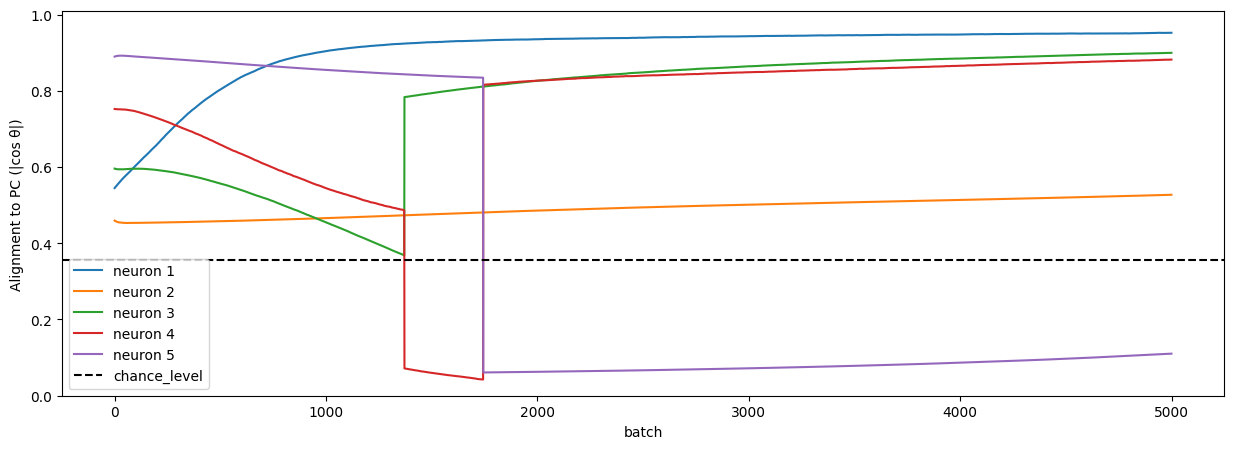

In [38]:
### 5.2 First order mode
model = LeenCompletePCA(d, m, eta_w=2e-4, eta_q=5e-3, C=3.0,
                       ema_alpha=0.05, symmetrize_q=True, seed=None, mode="first_order")
training_testing(model, X, number_of_samples, m)

step    0 | angle=  0.0° | best|corr|=[0.985 0.427 0.325 0.65  0.851]
step  100 | angle=  0.0° | best|corr|=[0.984 0.425 0.33  0.648 0.856]
step  200 | angle=  0.0° | best|corr|=[0.984 0.424 0.336 0.646 0.859]
step  300 | angle=  0.0° | best|corr|=[0.983 0.424 0.34  0.645 0.862]
step  400 | angle=  0.0° | best|corr|=[0.983 0.423 0.344 0.644 0.865]
step  500 | angle=  0.0° | best|corr|=[0.982 0.422 0.348 0.641 0.867]
step  600 | angle=  0.0° | best|corr|=[0.981 0.42  0.353 0.639 0.871]
step  700 | angle=  0.0° | best|corr|=[0.981 0.419 0.358 0.637 0.874]
step  800 | angle=  0.0° | best|corr|=[0.981 0.418 0.364 0.636 0.877]
step  900 | angle=  0.0° | best|corr|=[0.98  0.417 0.37  0.634 0.88 ]
step 1000 | angle=  0.0° | best|corr|=[0.979 0.416 0.376 0.632 0.883]
step 1100 | angle=  0.0° | best|corr|=[0.98  0.415 0.381 0.63  0.886]
step 1200 | angle=  0.0° | best|corr|=[0.979 0.413 0.387 0.628 0.889]
step 1300 | angle=  0.0° | best|corr|=[0.978 0.413 0.392 0.626 0.891]
step 1400 | angle=  

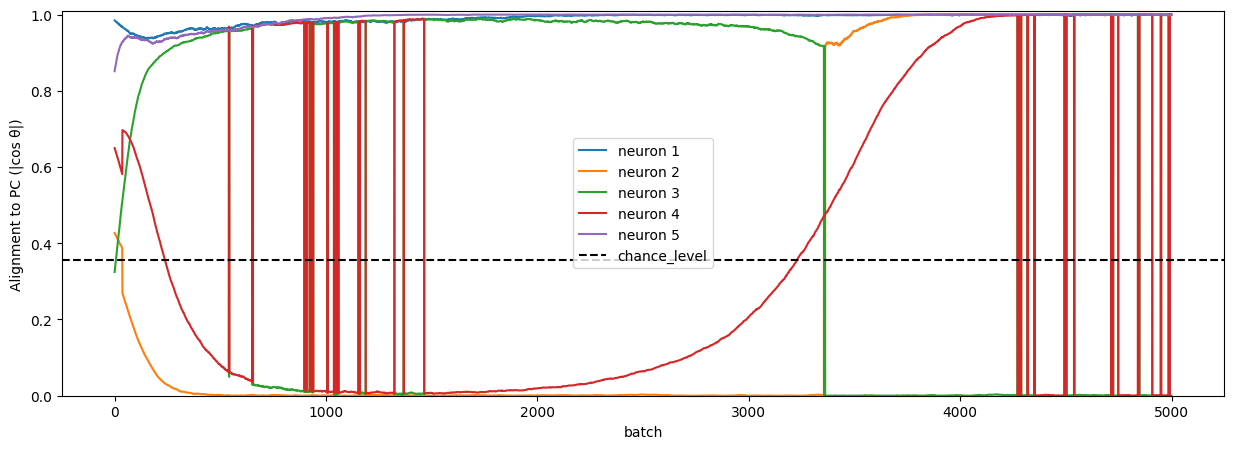

In [37]:
### 5.3 Minimal mode
model = LeenMinimalPCA(d, m, eta_w=3e-3, eta_q=1.5e-1, C=1.8,
                        ema_alpha=0.1,
                        clip_q_spectral=0.9, seed=None)
training_testing(model, X, number_of_samples, m)


### 3 Neurons test case

### 3.1 Complete mode

In [34]:
d = 3
m = 3
number_of_samples = 500000
X = generate_samples(d, number_of_samples)
eigenvalues, eigenvectors = compute_eigen_decomposition(X, center_data=True, return_covariance=False)
print(f"eigenvalues: {eigenvalues}, eigenvectors: {eigenvectors}")


eigenvalues: [5.53514067 2.77241292 0.88398066], eigenvectors: [[-0.45064251  0.82960278  0.32966734]
 [ 0.88323948  0.4679816   0.02968575]
 [ 0.12965087 -0.30455288  0.94363033]]


step    0 | angle=  0.0° | best|corr|=[0.941 0.849 0.54 ]
step  100 | angle=  0.0° | best|corr|=[0.941 0.85  0.54 ]
step  200 | angle=  0.0° | best|corr|=[0.941 0.85  0.54 ]
step  300 | angle=  0.0° | best|corr|=[0.941 0.85  0.54 ]
step  400 | angle=  0.0° | best|corr|=[0.941 0.85  0.54 ]
step  500 | angle=  0.0° | best|corr|=[0.941 0.85  0.54 ]
step  600 | angle=  0.0° | best|corr|=[0.941 0.85  0.54 ]
step  700 | angle=  0.0° | best|corr|=[0.941 0.85  0.539]
step  800 | angle=  0.0° | best|corr|=[0.941 0.851 0.539]
step  900 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1000 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1100 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1200 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1300 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1400 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1500 | angle=  0.0° | best|corr|=[0.94  0.851 0.539]
step 1600 | angle=  0.0° | best|corr|=[0.94  0.852 0.539]
step 1700 | an

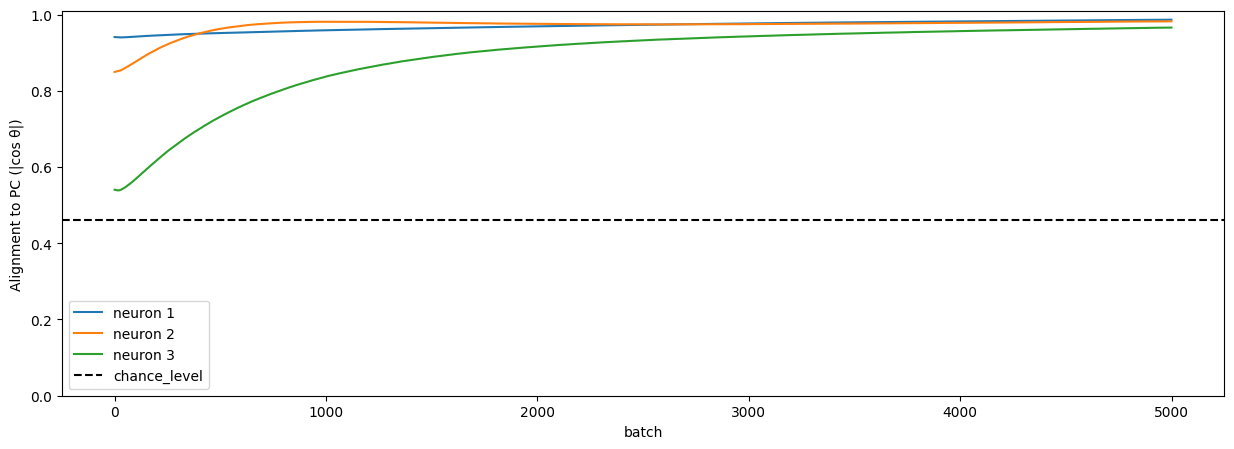

In [35]:
# 3.1 Complete mode
model = LeenCompletePCA(d, m, eta_w=2e-4, eta_q=5e-3, C=3.0,
                       ema_alpha=0.05, symmetrize_q=True, seed=None, mode="complete")

training_testing(model, X, number_of_samples, m)

step    0 | angle=  0.0° | best|corr|=[0.988 0.763 0.878]
step  100 | angle=  0.0° | best|corr|=[0.988 0.762 0.878]
step  200 | angle=  0.0° | best|corr|=[0.988 0.762 0.878]
step  300 | angle=  0.0° | best|corr|=[0.988 0.762 0.878]
step  400 | angle=  0.0° | best|corr|=[0.988 0.761 0.878]
step  500 | angle=  0.0° | best|corr|=[0.988 0.761 0.878]
step  600 | angle=  0.0° | best|corr|=[0.988 0.761 0.878]
step  700 | angle=  0.0° | best|corr|=[0.988 0.761 0.877]
step  800 | angle=  0.0° | best|corr|=[0.988 0.761 0.877]
step  900 | angle=  0.0° | best|corr|=[0.988 0.76  0.877]
step 1000 | angle=  0.0° | best|corr|=[0.988 0.76  0.877]
step 1100 | angle=  0.0° | best|corr|=[0.988 0.76  0.877]
step 1200 | angle=  0.0° | best|corr|=[0.988 0.76  0.877]
step 1300 | angle=  0.0° | best|corr|=[0.988 0.76  0.877]
step 1400 | angle=  0.0° | best|corr|=[0.988 0.76  0.877]
step 1500 | angle=  0.0° | best|corr|=[0.989 0.76  0.877]
step 1600 | angle=  0.0° | best|corr|=[0.989 0.76  0.877]
step 1700 | an

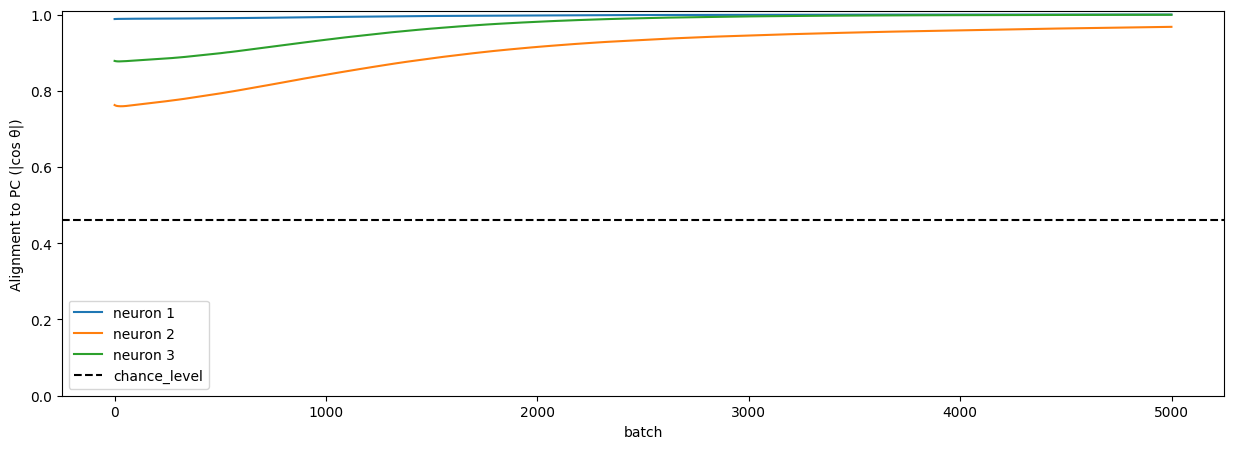

In [10]:
### 3.2 First order mode
model = LeenCompletePCA(d, m, eta_w=2e-4, eta_q=5e-3, C=3.0,
                       ema_alpha=0.05, symmetrize_q=True, seed=None, mode="first_order")
training_testing(model, X, number_of_samples, m)


step    0 | angle=  0.0° | best|corr|=[0.762 0.722 0.688]
step  100 | angle=  0.0° | best|corr|=[0.764 0.721 0.688]
step  200 | angle=  0.0° | best|corr|=[0.765 0.72  0.688]
step  300 | angle=  0.0° | best|corr|=[0.766 0.719 0.689]
step  400 | angle=  0.0° | best|corr|=[0.767 0.718 0.689]
step  500 | angle=  0.0° | best|corr|=[0.769 0.716 0.689]
step  600 | angle=  0.0° | best|corr|=[0.769 0.715 0.69 ]
step  700 | angle=  0.0° | best|corr|=[0.771 0.715 0.69 ]
step  800 | angle=  0.0° | best|corr|=[0.773 0.714 0.691]
step  900 | angle=  0.0° | best|corr|=[0.774 0.713 0.691]
step 1000 | angle=  0.0° | best|corr|=[0.774 0.713 0.692]
step 1100 | angle=  0.0° | best|corr|=[0.775 0.713 0.693]
step 1200 | angle=  0.0° | best|corr|=[0.775 0.712 0.693]
step 1300 | angle=  0.0° | best|corr|=[0.776 0.712 0.694]
step 1400 | angle=  0.0° | best|corr|=[0.777 0.711 0.694]
step 1500 | angle=  0.0° | best|corr|=[0.777 0.711 0.694]
step 1600 | angle=  0.0° | best|corr|=[0.778 0.71  0.695]
step 1700 | an

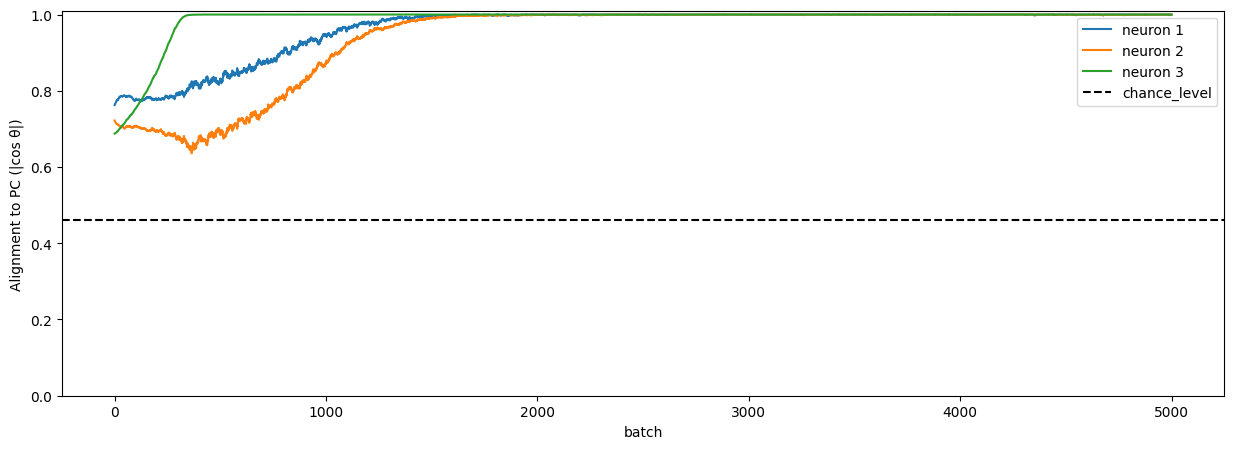

In [25]:
### 3.3 Minimal mode
model = LeenMinimalPCA(d, m, eta_w=3e-3, eta_q=1.5e-1, C=1.8,
                        ema_alpha=0.1,
                        clip_q_spectral=0.9, seed=None)
training_testing(model, X, number_of_samples, m)

### 2 Neurons test case

In [28]:
d, m = 2, 2
number_of_samples = 100000
X = generate_samples(d, number_of_samples)
eigenvalues, eigenvectors = compute_eigen_decomposition(X, center_data=True, return_covariance=False)
print(f"eigenvalues: {eigenvalues}, eigenvectors: {eigenvectors}")



eigenvalues: [10.73926759  0.11988019], eigenvectors: [[-0.94362802  0.3310078 ]
 [-0.3310078  -0.94362802]]


step    0 | angle=  0.0° | best|corr|=[0.999 0.856]
step  100 | angle=  0.0° | best|corr|=[0.999 0.857]
step  200 | angle=  0.0° | best|corr|=[0.999 0.857]
step  300 | angle=  0.0° | best|corr|=[0.999 0.858]
step  400 | angle=  0.0° | best|corr|=[0.999 0.858]
step  500 | angle=  0.0° | best|corr|=[0.999 0.859]
step  600 | angle=  0.0° | best|corr|=[0.999 0.859]
step  700 | angle=  0.0° | best|corr|=[0.999 0.86 ]
step  800 | angle=  0.0° | best|corr|=[0.999 0.86 ]
step  900 | angle=  0.0° | best|corr|=[0.999 0.861]
step 1000 | angle=  0.0° | best|corr|=[0.999 0.861]
step 1100 | angle=  0.0° | best|corr|=[0.999 0.861]
step 1200 | angle=  0.0° | best|corr|=[0.999 0.862]
step 1300 | angle=  0.0° | best|corr|=[0.999 0.862]
step 1400 | angle=  0.0° | best|corr|=[0.999 0.863]
step 1500 | angle=  0.0° | best|corr|=[0.999 0.863]
step 1600 | angle=  0.0° | best|corr|=[0.999 0.864]
step 1700 | angle=  0.0° | best|corr|=[0.999 0.864]
step 1800 | angle=  0.0° | best|corr|=[0.999 0.865]
step 1900 | 

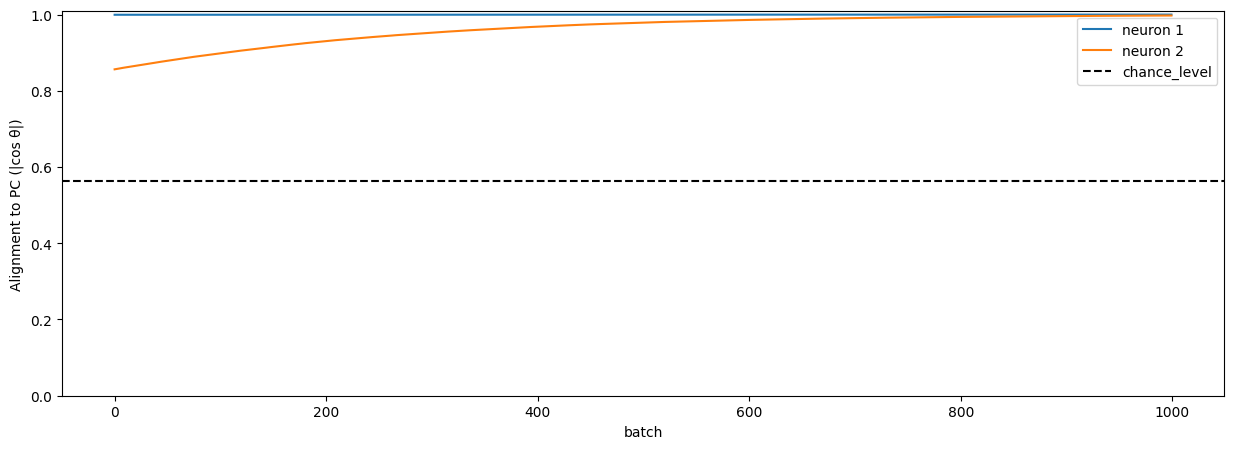

In [32]:
# 2.1 Complete mode
model = LeenCompletePCA(d, m, eta_w=2e-4, eta_q=5e-3, C=3.0,
                       ema_alpha=0.05, symmetrize_q=True, seed=None, mode="complete")

training_testing(model, X, number_of_samples, m)

step    0 | angle=  0.0° | best|corr|=[0.592 0.92 ]
step  100 | angle=  0.0° | best|corr|=[0.593 0.92 ]
step  200 | angle=  0.0° | best|corr|=[0.593 0.92 ]
step  300 | angle=  0.0° | best|corr|=[0.594 0.92 ]
step  400 | angle=  0.0° | best|corr|=[0.595 0.919]
step  500 | angle=  0.0° | best|corr|=[0.596 0.919]
step  600 | angle=  0.0° | best|corr|=[0.597 0.919]
step  700 | angle=  0.0° | best|corr|=[0.597 0.918]
step  800 | angle=  0.0° | best|corr|=[0.598 0.918]
step  900 | angle=  0.0° | best|corr|=[0.599 0.918]
step 1000 | angle=  0.0° | best|corr|=[0.599 0.918]
step 1100 | angle=  0.0° | best|corr|=[0.6   0.918]
step 1200 | angle=  0.0° | best|corr|=[0.6   0.918]
step 1300 | angle=  0.0° | best|corr|=[0.601 0.918]
step 1400 | angle=  0.0° | best|corr|=[0.601 0.917]
step 1500 | angle=  0.0° | best|corr|=[0.602 0.917]
step 1600 | angle=  0.0° | best|corr|=[0.603 0.917]
step 1700 | angle=  0.0° | best|corr|=[0.603 0.917]
step 1800 | angle=  0.0° | best|corr|=[0.604 0.917]
step 1900 | 

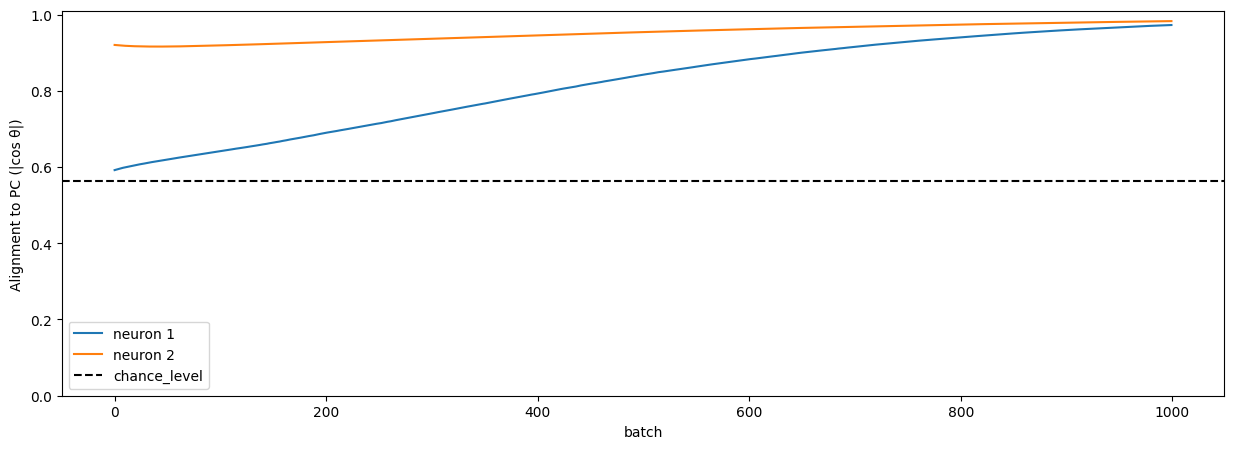

In [30]:
# 2.2 First order mode
model = LeenCompletePCA(d, m, eta_w=2e-4, eta_q=5e-3, C=3.0,
                       ema_alpha=0.05, symmetrize_q=True, seed=None, mode="first_order")
training_testing(model, X, number_of_samples, m)


step    0 | angle=  0.0° | best|corr|=[0.991 0.61 ]
step  100 | angle=  0.0° | best|corr|=[0.991 0.611]
step  200 | angle=  0.0° | best|corr|=[0.991 0.613]
step  300 | angle=  0.0° | best|corr|=[0.991 0.614]
step  400 | angle=  0.0° | best|corr|=[0.992 0.617]
step  500 | angle=  0.0° | best|corr|=[0.992 0.619]
step  600 | angle=  0.0° | best|corr|=[0.992 0.621]
step  700 | angle=  0.0° | best|corr|=[0.992 0.623]
step  800 | angle=  0.0° | best|corr|=[0.992 0.625]
step  900 | angle=  0.0° | best|corr|=[0.993 0.627]
step 1000 | angle=  0.0° | best|corr|=[0.993 0.628]
step 1100 | angle=  0.0° | best|corr|=[0.993 0.63 ]
step 1200 | angle=  0.0° | best|corr|=[0.993 0.632]
step 1300 | angle=  0.0° | best|corr|=[0.993 0.634]
step 1400 | angle=  0.0° | best|corr|=[0.993 0.636]
step 1500 | angle=  0.0° | best|corr|=[0.993 0.638]
step 1600 | angle=  0.0° | best|corr|=[0.994 0.64 ]
step 1700 | angle=  0.0° | best|corr|=[0.994 0.642]
step 1800 | angle=  0.0° | best|corr|=[0.994 0.644]
step 1900 | 

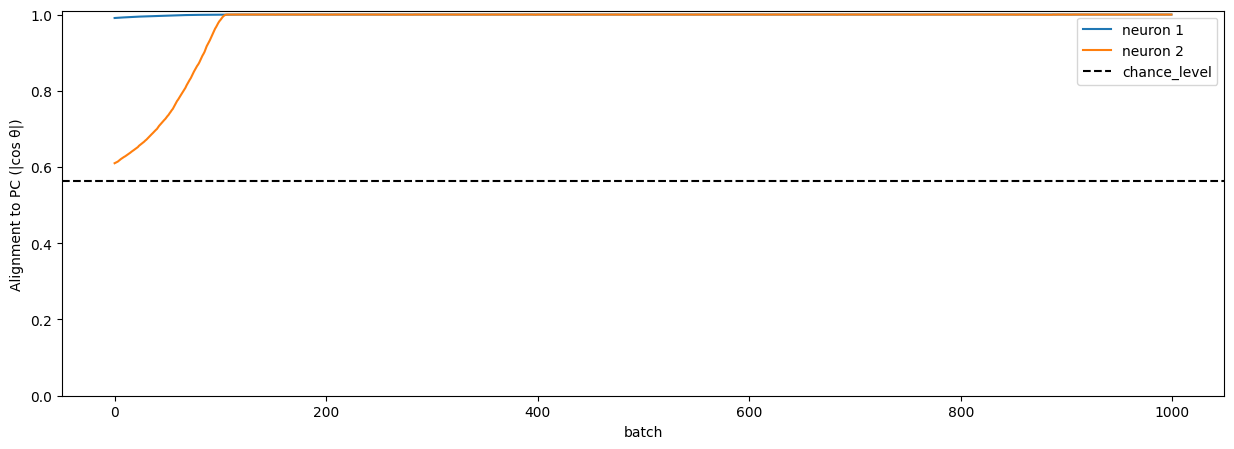

In [31]:
# 2.3 Minimal mode
model = LeenMinimalPCA(d, m, eta_w=3e-3, eta_q=1.5e-1, C=1.8,
                        ema_alpha=0.1,
                        clip_q_spectral=0.9, seed=None)
training_testing(model, X, number_of_samples, m)